In [7]:
import numpy as np
import sympy as smp
from sympy.vector import *
import matplotlib.pyplot as plt
from scipy.integrate import quad, quad_vec

In [10]:
x, y, z, u1, u2, u3, v1, v2, v3, t = smp.symbols('x y z u_1 u_2 u_3 v_1 v_2 v_3 t')

## Vectors and Geometry

### Numerical or symbolic

In [12]:
a = np.array([1,2,3])
b = np.array([7,8,9])
u = smp.Matrix([u1, u2, u3])
v = smp.Matrix([v1, v2, v3])

In [16]:
2*u + v

Matrix([
[2*u_1 + v_1],
[2*u_2 + v_2],
[2*u_3 + v_3]])

In [20]:
u.cross(v)

Matrix([
[ u_2*v_3 - u_3*v_2],
[-u_1*v_3 + u_3*v_1],
[ u_1*v_2 - u_2*v_1]])

### Vector projection

In [21]:
proj_b_a = np.dot(a, b)/np.linalg.norm(b)**2 * b
proj_b_a

array([1.80412371, 2.06185567, 2.31958763])

In [23]:
proj_u_v = u.dot(v)/v.norm()**2 * v
proj_u_v

Matrix([
[v_1*(u_1*v_1 + u_2*v_2 + u_3*v_3)/(Abs(v_1)**2 + Abs(v_2)**2 + Abs(v_3)**2)],
[v_2*(u_1*v_1 + u_2*v_2 + u_3*v_3)/(Abs(v_1)**2 + Abs(v_2)**2 + Abs(v_3)**2)],
[v_3*(u_1*v_1 + u_2*v_2 + u_3*v_3)/(Abs(v_1)**2 + Abs(v_2)**2 + Abs(v_3)**2)]])

## Lines or Planes in Space

In [24]:
# r = r0 + v*t equation on line
r0 = smp.Matrix([1,1,1])
v = smp.Matrix([1,3,-1])
r = r0 + t*v
r

Matrix([
[  t + 1],
[3*t + 1],
[  1 - t]])

In [26]:
# n*(p0 - (x,y,z)) = 0
p0 = smp.Matrix([-3, 6,3])
r = smp.Matrix([x, y, z])
n = smp.Matrix([1,1,1])
n.dot(p0-r)

-x - y - z + 6

**Example** Find vector parallel to the line of intersection of the two planes `3x - 6y - 2x = 15` and `2x + y - 2z = 5`.

In [27]:
n1 = np.array([3, -6, -2])
n2 = np.array([2, 1, -2])
ans = np.cross(n1, n2)
ans

array([14,  2, 15])

ans : `14x + 2y + 15xz = 0`

## Vector calculus

### vector derivatives

In [29]:
r = smp.Matrix([3*t, smp.sin(t), t**2])
r

Matrix([
[   3*t],
[sin(t)],
[  t**2]])

In [30]:
smp.diff(r, t)

Matrix([
[     3],
[cos(t)],
[   2*t]])

In [31]:
smp.integrate(r, t)

Matrix([
[3*t**2/2],
[ -cos(t)],
[  t**3/3]])

**Example:** Find the angle between the velocity and acceleration as a function of time `t`.

In [37]:
v = smp.diff(r, t)
a = smp.diff(v, t)
theta = smp.acos(v.dot(a)/(v.norm()*a.norm())).simplify()
theta

acos((4*t - sin(2*t)/2)/(sqrt(Abs(sin(t))**2 + 4)*sqrt(4*Abs(t)**2 + Abs(cos(t))**2 + 9)))

In [40]:
theta.subs(t, 6).evalf()

0.251108015692338

In [42]:
f = smp.lambdify([t], theta)
f(6)

np.float64(0.25110801569233787)

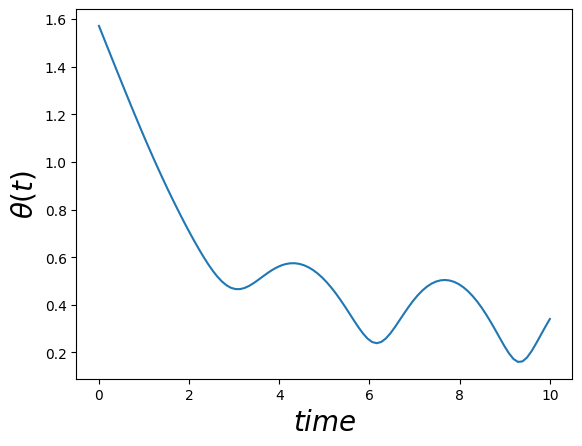

In [48]:
tt = np.linspace(0, 10, 100)
aa = smp.lambdify([t], theta)(tt)
plt.plot(tt, aa)
plt.xlabel('$time$', fontsize=20)
plt.ylabel(r'$\theta(t)$', fontsize=20)
plt.show()

## Vector integrals

In [55]:
r = smp.Matrix([smp.exp(t)*smp.cos(t), t**4, 1/(1 + t**2)])
r

Matrix([
[exp(t)*cos(t)],
[         t**4],
[ 1/(t**2 + 1)]])

In [53]:
smp.Integral(r).doit()

Matrix([
[exp(t)*sin(t)/2 + exp(t)*cos(t)/2],
[                           t**5/5],
[                          atan(t)]])

In [54]:
smp.integrate(r, t)

Matrix([
[exp(t)*sin(t)/2 + exp(t)*cos(t)/2],
[                           t**5/5],
[                          atan(t)]])

In some case integral cannot be evaluated symbolically, must solve difint integrals numerically

In [56]:
r = smp.Matrix([smp.exp(t**2)*smp.cos(t)**3, smp.exp(-1*t**4), 1/(3 + t**2)])
r

Matrix([
[exp(t**2)*cos(t)**3],
[         exp(-t**4)],
[       1/(t**2 + 3)]])